In [2]:
# Step 0: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plot design standard
sns.set_theme(style="whitegrid")


# 1. Load the Mall Customers Dataset from an active public mirror repository
url = 'https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv'
df = pd.read_csv(url)

print("--- Step 1: Mall Customers Dataset Loaded ---")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print("First 5 records of raw data:")
display(df.head())

# Feature Selection: We extract Annual Income (k$) and Spending Score (1-100)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

--- Step 1: Mall Customers Dataset Loaded ---
Dataset shape: 200 rows, 5 columns.

First 5 records of raw data:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 2. Scale features (Crucial step since K-Means relies heavily on geometric distances)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n--- Step 2: Feature Transformation Complete ---")


--- Step 2: Feature Transformation Complete ---



--- Step 3: Computing Within-Cluster Sum of Squares (WCSS) ---


C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set

Success! 'elbow_method_plot.png' generated and saved locally.


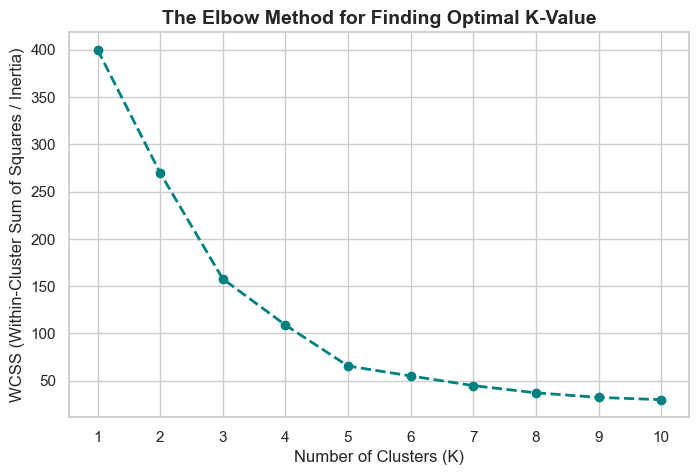

In [4]:
# 3. Use the Elbow Method to determine the optimal value of K
print("\n--- Step 3: Computing Within-Cluster Sum of Squares (WCSS) ---")
wcss = []
# Evaluate structural variance across 1 to 10 potential clusters
for k in range(1, 11):
    # 'k-means++' guarantees optimal initial centroid spacing
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Render and Save the Elbow Plot Visualization
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal', linewidth=2)
plt.title('The Elbow Method for Finding Optimal K-Value', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares / Inertia)', fontsize=12)
plt.xticks(range(1, 11))

plt.savefig('elbow_method_plot.png', dpi=300, bbox_inches='tight')
print("Success! 'elbow_method_plot.png' generated and saved locally.")
plt.show()

In [5]:
# 4. Perform Cluster Assignment using the Optimal K Value
# Looking at the graph break, K=5 is the clear "elbow point" where inertia levels off
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster_Labels'] = final_kmeans.fit_predict(X_scaled)

print("\n--- Step 4: Cluster Assignment Complete ---")
print("First 5 rows showcasing finalized consumer classification tags:")
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_Labels']].head())

# Export the cluster labels report document as requested in deliverables
df.to_csv('mall_customer_cluster_labels.csv', index=False)
print("Success! 'mall_customer_cluster_labels.csv' saved locally.")


--- Step 4: Cluster Assignment Complete ---
First 5 rows showcasing finalized consumer classification tags:
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster_Labels
0           1                  15                      39               4
1           2                  15                      81               2
2           3                  16                       6               4
3           4                  16                      77               2
4           5                  17                      40               4
Success! 'mall_customer_cluster_labels.csv' saved locally.


C:\Users\rohit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



--- Step 5: Visualizing Final Segmentation Map ---
Success! 'final_customer_clusters.png' saved locally.


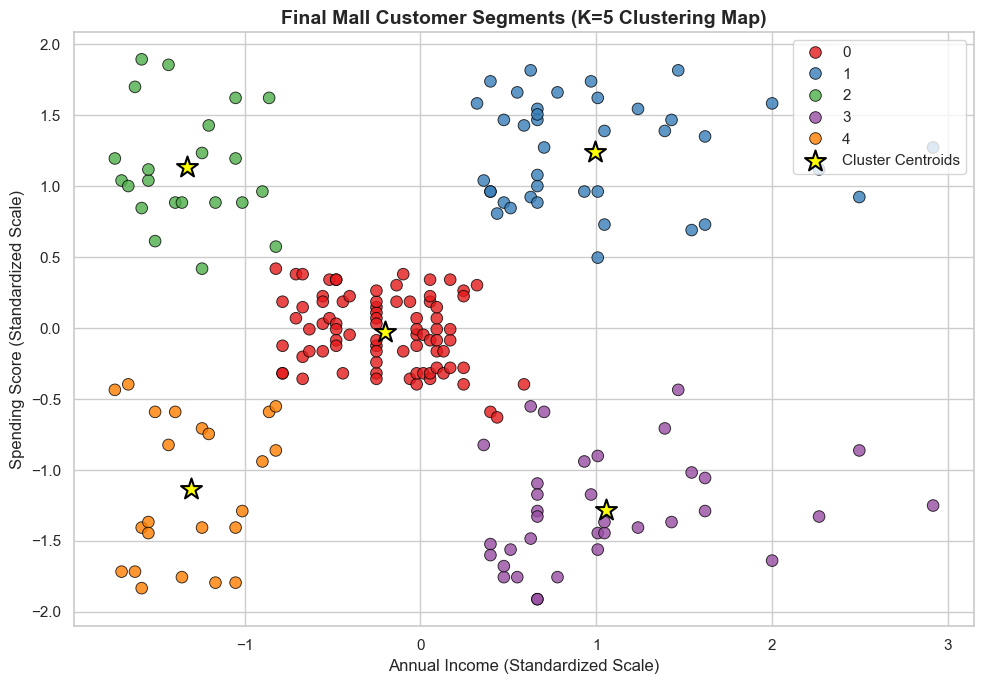

In [6]:
# 5. Visualize Clusters and Centroids spatial mapping
print("\n--- Step 5: Visualizing Final Segmentation Map ---")
plt.figure(figsize=(10, 7))

# Plot scaled consumer scatter patterns colored by assigned clusters
sns.scatterplot(
    x=X_scaled[:, 0], 
    y=X_scaled[:, 1], 
    hue=df['Cluster_Labels'], 
    palette='Set1', 
    s=70, 
    edgecolor='black', 
    alpha=0.8
)

# Extract and superimpose the trained mathematical centers (centroids)
centroids = final_kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=250, 
    c='yellow', 
    marker='*', 
    edgecolor='black', 
    linewidth=1.5, 
    label='Cluster Centroids'
)

plt.title('Final Mall Customer Segments (K=5 Clustering Map)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (Standardized Scale)', fontsize=12)
plt.ylabel('Spending Score (Standardized Scale)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()

plt.savefig('final_customer_clusters.png', dpi=300)
print("Success! 'final_customer_clusters.png' saved locally.")
plt.show()